# Harmonic Transposition

This notebook shows how the harmonic transposition is done in order to match the target note.

In [1]:
# Enabling ipympl for interactive plots and styling the UI a bit
# get_ipython().run_line_magic('matplotlib', 'widget') # ipympl
get_ipython().run_cell_magic('html', '', '<style>.widget-readout { color: white; font-size: 1.2em; box-shadow: none !important ;} </style>') # style

import sys, os, datetime
import numpy as np
import pyaudio as pa
import matplotlib.pyplot as plt

sys.path.append('/sms-tools/software/models')
import utilFunctions as UF
import sineModel as SM
# import stochasticModel as STM

sys.path.append('../')
from utils.structures import Sound
from scipy.signal import resample, blackmanharris, triang, hanning
from scipy.fftpack import fft, ifft, fftshift
from scipy.io.wavfile import write
from ipywidgets import ( HTML, Layout, FloatSlider, Label, ToggleButton, Button, GridBox, interactive_output, interact )

# Constants
DEFAULT_DATA_FOLDER = '../../data'
DEFAULT_SOUNDS_FOLDER = DEFAULT_DATA_FOLDER + '/sounds'
DEFAULT_SOUND_FILE_1 = DEFAULT_SOUNDS_FOLDER + '/violin-B3.wav'
DEFAULT_SOUND_FILE_2 = DEFAULT_SOUNDS_FOLDER + '/soprano-E4.wav'
ANALYSIS_OUTPUT_FOLDER = DEFAULT_DATA_FOLDER + '/analysis_output'
MORPHINGS_OUTPUT_FOLDER = DEFAULT_DATA_FOLDER + 'morphing_output_test'

NS = 512 # size of fft used in synthesis
H = int(NS/4) # hop size (has to be 1/4 of NS) - 128
NUMBER_OF_FFT_SYNTH_FRAMES = 4 # number of FFT synth frames
FRAME_TO_PLOT = 0 # 100 # frame to plot
NUMBER_OF_FRAMES_TO_PLOT  = 8 # number of frames to plots
GENERATE_PLOTS = False # generate the plots

DARK_MODE = False

if (DARK_MODE):
    params = {
        "text.color" : "w",
        "ytick.color" : "w",
        "xtick.color" : "w",
        "axes.labelcolor" : "w",
        "axes.edgecolor" : "w",
#         "axes.facecolor" : 'e5e5e5'
    }
    plt.rcParams.update(params)

In [2]:
# Load the sounds by default
sound_1 = Sound(DEFAULT_SOUND_FILE_1)
sound_2 = Sound(DEFAULT_SOUND_FILE_2)

# Loading the .had files
sound_1.load_had_file()
sound_2.load_had_file()

# Empty sound where the morph will be generated 
sound_morph = Sound(DEFAULT_SOUND_FILE_2)

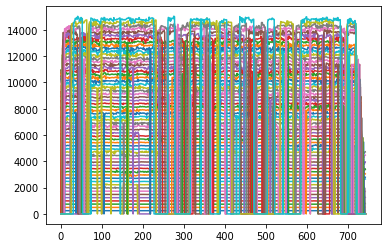

In [3]:
plt.plot(sound_1.analysis.output.values.hfreq)
plt.show()

In [4]:
%matplotlib inline
from ipywidgets import interactive
import matplotlib.pyplot as plt
import numpy as np

def hramonic_transposition(cycles_per_second):
    
    %config InlineBackend.figure_format = 'svg'
    
    plt.figure(figsize=(10,8))
#     plt.figure(figsize=(20,15))
    freqs = sound_1.analysis.output.values.hfreq
    
    # Recalculate the harmonics for the current midi note
    for i in range(0, len(freqs), 1):
        
        # Fundamental note of this frame (in Hz)
        current_fundamental = freqs[i][0];
    
        for j in range(0, len(freqs[i]), 1):
            freqs[i][j] = (freqs[i][j] / current_fundamental) * cycles_per_second
                
    freqs[ freqs==0 ] = np.nan

    plt.plot(freqs)
    plt.ylim(0, 15000)
    plt.show()

interactive_plot = interact(hramonic_transposition, cycles_per_second=(10.0, 1000.0))
# interactive_plot = interact_manual(f, cycles_per_second=(10.0, 1000.0), b=(-3, 3, 0.5))
# output = interactive_plot.children[-1]
# output.layout.height = '600px'
interactive_plot

interactive(children=(FloatSlider(value=505.0, description='cycles_per_second', max=1000.0, min=10.0), Output(…

<function __main__.hramonic_transposition(cycles_per_second)>